# REPLYNT Notebook 4: Needs Reply Predictor

This notebook predicts whether an email needs a reply using message text together with priority and intent. It compares Logistic Regression against XGBoost, reports holdout metrics and probability scores, explains the strongest model signals, and saves the final pipeline as `needs_reply_pipeline.pkl`.

In [1]:
import importlib
import subprocess
import sys

REQUIRED_PACKAGES = {
    "numpy": "numpy",
    "pandas": "pandas",
    "sklearn": "scikit-learn",
    "matplotlib": "matplotlib",
    "seaborn": "seaborn",
    "joblib": "joblib",
}

missing = []
for module_name, package_name in REQUIRED_PACKAGES.items():
    try:
        importlib.import_module(module_name)
    except ImportError:
        missing.append(package_name)

if missing:
    print("Installing missing packages:", ", ".join(missing))
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])
else:
    print("All base packages are already installed.")


try:
    import xgboost
    print("XGBoost already installed:", xgboost.__version__)
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "xgboost"])
    import xgboost
    print("Installed XGBoost:", xgboost.__version__)

All base packages are already installed.
XGBoost already installed: 3.2.0


In [2]:
from __future__ import annotations

import re
import warnings
from pathlib import Path
from typing import Iterable

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.calibration import CalibratedClassifierCV
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import LinearSVC

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 160)

RANDOM_STATE = 42
BASE_DIR = Path.home() / "Desktop" / "replynt_final"
DATA_DIR = BASE_DIR / "data"
NOTEBOOK_DIR = BASE_DIR / "notebooks"
MODELS_DIR = BASE_DIR / "models"
NOTEBOOK_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Data directory: {DATA_DIR}")
print(f"Notebook directory: {NOTEBOOK_DIR}")
print(f"Model directory: {MODELS_DIR}")

from xgboost import XGBClassifier

Data directory: C:\Users\mbmeg\Desktop\replynt_final\data
Notebook directory: C:\Users\mbmeg\Desktop\replynt_final\notebooks
Model directory: C:\Users\mbmeg\Desktop\replynt_final\models


In [3]:
def normalize_text(value: str) -> str:
    if pd.isna(value):
        return ""
    text = str(value).replace("\r", " ").replace("\n", " ")
    text = re.sub(r"https?://\S+|www\.\S+", " URL ", text, flags=re.IGNORECASE)
    text = re.sub(r"\S+@\S+", " EMAIL ", text)
    text = re.sub(r"[^a-zA-Z0-9$%!?.,:/\\-]+", " ", text)
    text = re.sub(r"\s+", " ", text).strip().lower()
    return text


def detect_csv(candidates: Iterable[str], required_columns: Iterable[str]) -> Path:
    required_columns = set(required_columns)
    candidates = [candidate.lower() for candidate in candidates]
    files = sorted(DATA_DIR.glob("*.csv"))

    for path in files:
        if any(candidate in path.name.lower() for candidate in candidates):
            preview = pd.read_csv(path, nrows=5)
            if required_columns.issubset(set(preview.columns)):
                return path

    for path in files:
        preview = pd.read_csv(path, nrows=5)
        if required_columns.issubset(set(preview.columns)):
            return path

    raise FileNotFoundError(
        f"Could not find a CSV in {DATA_DIR} matching names={candidates} and columns={sorted(required_columns)}"
    )


def safe_n_splits(y: pd.Series, default: int = 5) -> int:
    return max(2, min(default, int(y.value_counts().min())))


def metrics_frame(y_true, y_pred, average="macro") -> pd.DataFrame:
    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, average=average, zero_division=0),
        "recall": recall_score(y_true, y_pred, average=average, zero_division=0),
        "f1": f1_score(y_true, y_pred, average=average, zero_division=0),
    }
    return pd.DataFrame([metrics]).round(4)


def plot_confusion(y_true, y_pred, labels):
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    cm_df = pd.DataFrame(cm, index=labels, columns=labels)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")
    plt.tight_layout()
    plt.show()
    return cm_df


def summarize_cv(results: dict, model_name: str) -> pd.DataFrame:
    frame = pd.DataFrame(results)
    keep = [col for col in frame.columns if col.startswith("test_")]
    summary = frame[keep].agg(["mean", "std"]).T.reset_index()
    summary.columns = ["metric", f"{model_name}_mean", f"{model_name}_std"]
    summary["metric"] = summary["metric"].str.replace("test_", "", regex=False)
    return summary

reply_path = detect_csv(["triage", "reply"], ["needs_reply", "priority", "intent"])
print(f"Using dataset: {reply_path}")

df = pd.read_csv(reply_path)
subject_text = df.get("subject", pd.Series("", index=df.index)).fillna("").astype(str)
body_text = df.get("body", pd.Series("", index=df.index)).fillna("").astype(str)
combined_text = df.get("combined_text", pd.Series("", index=df.index)).fillna("").astype(str)

fallback_text = subject_text + " " + body_text
df["email_text"] = np.where(combined_text.str.strip().eq(""), fallback_text, combined_text)
df["email_text"] = pd.Series(df["email_text"], index=df.index).map(normalize_text)
df["priority"] = df["priority"].astype(str).str.strip()
df["intent"] = df["intent"].astype(str).str.strip()
df["needs_reply"] = df["needs_reply"].astype(str).str.strip()
df = df[df["needs_reply"].isin(["Yes", "No"])].reset_index(drop=True)

label_map = {"No": 0, "Yes": 1}
inverse_label_map = {value: key for key, value in label_map.items()}

display(df[["email_text", "priority", "intent", "needs_reply"]].head())
display(df["needs_reply"].value_counts().to_frame("count"))

Using dataset: C:\Users\mbmeg\Desktop\replynt_final\data\triage_train_FINAL.csv


,email_text,priority,intent,needs_reply
0,"july product roundup hello readers, welcome to our july newsletter. this edition highlights customer stories, a few customer wins, and several practical tip...",P3,Newsletter,No
1,"would 2:30 pm on by eod work? hi alex, i would like to set up a meeting to discuss launch readiness. please share a convenient time this week.",P2,Meeting Request,Yes
2,"idea to help brightline logistics surface urgent issues sooner hi reese, if you are exploring ways to streamline the marketing workflow, i would love to sho...",P2,Sales Outreach,Yes
3,"quote request for data warehouse hello, could you share a formal quote for the data warehouse and any annual pricing details? the finance team needs the num...",P1,Quote Request,Yes
4,"friendly reminder: outstanding balance on inv-03828 hello casey, this is a reminder that invoice inv-03828 for $8,200 is due april 28. please confirm the pa...",P1,Payment Reminder,Yes


,count
needs_reply,
Yes,6985
No,1832


In [4]:
X = df[["email_text", "priority", "intent"]].copy()
y = df["needs_reply"].map(label_map)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE,
)

cv = StratifiedKFold(
    n_splits=safe_n_splits(pd.Series(y_train), default=5),
    shuffle=True,
    random_state=RANDOM_STATE,
)

In [5]:
feature_builder = ColumnTransformer(
    transformers=[
        (
            "text",
            TfidfVectorizer(
                ngram_range=(1, 2),
                min_df=2,
                max_df=0.98,
                sublinear_tf=True,
                strip_accents="unicode",
            ),
            "email_text",
        ),
        (
            "categorical",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("onehot", OneHotEncoder(handle_unknown="ignore")),
                ]
            ),
            ["priority", "intent"],
        ),
    ]
)

logistic_pipeline = Pipeline(
    steps=[
        ("features", feature_builder),
        ("classifier", LogisticRegression(max_iter=4000, class_weight="balanced", random_state=RANDOM_STATE)),
    ]
)

negative_count = int((y_train == 0).sum())
positive_count = int((y_train == 1).sum())
scale_pos_weight = negative_count / max(positive_count, 1)

xgb_pipeline = Pipeline(
    steps=[
        ("features", feature_builder),
        (
            "classifier",
            XGBClassifier(
                objective="binary:logistic",
                n_estimators=300,
                max_depth=5,
                learning_rate=0.08,
                subsample=0.9,
                colsample_bytree=0.8,
                min_child_weight=2,
                reg_lambda=1.0,
                eval_metric="logloss",
                scale_pos_weight=scale_pos_weight,
                random_state=RANDOM_STATE,
                n_jobs=4,
                tree_method="hist",
            ),
        ),
    ]
)

models = {"Logistic Regression": logistic_pipeline, "XGBoost": xgb_pipeline}
scoring = {
    "accuracy": "accuracy",
    "precision": "precision_macro",
    "recall": "recall_macro",
    "f1": "f1_macro",
}

cv_tables = []
cv_scores = {}
for name, model in models.items():
    scores = cross_validate(model, X_train, y_train, cv=cv, scoring=scoring, n_jobs=1)
    cv_tables.append(summarize_cv(scores, name))
    cv_scores[name] = scores["test_f1"].mean()

cv_report = cv_tables[0]
for table in cv_tables[1:]:
    cv_report = cv_report.merge(table, on="metric", how="outer")

display(cv_report.round(4))
best_model_name = max(cv_scores, key=cv_scores.get)
best_model = models[best_model_name]
print("Selected model:", best_model_name)

,metric,Logistic Regression_mean,Logistic Regression_std,XGBoost_mean,XGBoost_std
0,accuracy,1.0,0.0,0.9996,0.0006
1,f1,1.0,0.0,0.9994,0.0010
2,precision,1.0,0.0,0.9990,0.0015
3,recall,1.0,0.0,0.9997,0.0004


Selected model: Logistic Regression


,accuracy,precision,recall,f1
0,1.0,1.0,1.0,1.0


              precision    recall  f1-score   support

          No       1.00      1.00      1.00       367
         Yes       1.00      1.00      1.00      1397

    accuracy                           1.00      1764
   macro avg       1.00      1.00      1.00      1764
weighted avg       1.00      1.00      1.00      1764



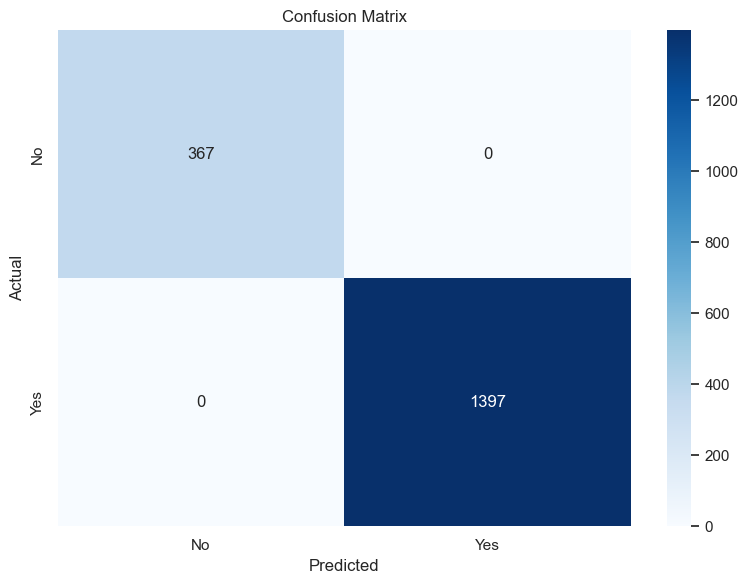

,No,Yes
No,367,0
Yes,0,1397


In [6]:
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

y_test_labels = pd.Series(y_test).map(inverse_label_map)
y_pred_labels = pd.Series(y_pred).map(inverse_label_map)

display(metrics_frame(y_test_labels, y_pred_labels, average="macro"))
print(classification_report(y_test_labels, y_pred_labels, zero_division=0))
confusion_df = plot_confusion(y_test_labels, y_pred_labels, labels=["No", "Yes"])
display(confusion_df)

## Probability Scores and Explainability

We inspect holdout probabilities for the positive class (`Yes`) and show feature importance from the selected classifier.

In [7]:
probabilities = best_model.predict_proba(X_test)
probability_table = X_test.copy()
probability_table["actual"] = y_test_labels.values
probability_table["predicted"] = y_pred_labels.values
probability_table["probability_yes"] = probabilities[:, 1]
display(probability_table.head(10))

feature_names = best_model.named_steps["features"].get_feature_names_out()
classifier = best_model.named_steps["classifier"]

if best_model_name == "Logistic Regression":
    importance = pd.DataFrame(
        {
            "feature": feature_names,
            "coefficient": classifier.coef_[0],
            "abs_coefficient": np.abs(classifier.coef_[0]),
        }
    ).sort_values("abs_coefficient", ascending=False)
    display(importance.head(25)[["feature", "coefficient"]])
else:
    importance = pd.DataFrame({"feature": feature_names, "importance": classifier.feature_importances_})
    display(importance.sort_values("importance", ascending=False).head(25))

,email_text,priority,intent,actual,predicted,probability_yes
939,enquiry on digital marketing services i am interested in learning about digital marketing services to help my business grow. could you provide details on th...,P1,Support Request,Yes,Yes,0.999292
7154,"idea to improve forecast review hello jordan, we help teams like harbor finance improve forecast review. would a short intro call be useful?",P2,Sales Outreach,Yes,Yes,0.998110
3436,"unresolved issue with the customer portal hello, we noticed an incorrect charge tied to inv-03443 for $240. this is unacceptable because the services were n...",P1,Complaint,Yes,Yes,0.999363
7207,"reminder on the open action items hello taylor, following up on board prep. could you confirm the current status and let me know if we are still on track fo...",P2,Follow Up,Yes,Yes,0.999595
7151,support required for campaign the campaign did not meet expectations due to incorrect targeting,P1,Support Request,Yes,Yes,0.999250
3367,"product update for the mobile app hello, we just shipped q4 faster search. the update improves reliability and gives teams better visibility into security r...",P3,Product Update,No,No,0.002738
1528,"can i share a quick demo for automation workflow workflows? hi taylor, i noticed your team is focused on open action items. we help operations teams reduce ...",P2,Sales Outreach,Yes,Yes,0.998133
2305,"would you be available for round 2? hi morgan, could you confirm your availability for a 45-minute interview with the finance team? we are hoping to wrap up...",P2,Interview Request,Yes,Yes,0.998285
4045,"meeting request for the marketing team hi alex, please let me know whether 1:00 pm on by eod is workable for a short discussion about onboarding checklist.",P2,Meeting Request,Yes,Yes,0.999561
4201,"unresolved issue with the export service hello team, i am frustrated because invoice totals are incorrect and we still do not have a clear resolution. this ...",P1,Complaint,Yes,Yes,0.999322


,feature,coefficient
10847,categorical__intent_Product Update,-4.207963
10841,categorical__intent_Internal FYI,-3.544852
10838,categorical__priority_P3,-3.508413
10845,categorical__intent_Newsletter,-3.441343
10837,categorical__priority_P2,2.829719
10836,categorical__priority_P1,2.561533
10840,categorical__intent_Follow Up,2.063248
10839,categorical__intent_Complaint,2.048430
10844,categorical__intent_Meeting Request,2.044147
10850,categorical__intent_Support Request,2.024022


In [8]:
model_path = MODELS_DIR / "needs_reply_pipeline.pkl"
joblib.dump(best_model, model_path)
print(f"Saved model to: {model_path}")

Saved model to: C:\Users\mbmeg\Desktop\replynt_final\models\needs_reply_pipeline.pkl


In [9]:
sample_email = pd.DataFrame(
    {
        "email_text": [normalize_text("Please review the payment issue and confirm whether we should respond to the customer today.")],
        "priority": ["P1"],
        "intent": ["Payment Reminder"],
    }
)

sample_prediction = pd.Series(best_model.predict(sample_email)).map(inverse_label_map)
sample_probability = best_model.predict_proba(sample_email)[:, 1]

sample_output = sample_email.copy()
sample_output["predicted_needs_reply"] = sample_prediction.values
sample_output["probability_yes"] = sample_probability
display(sample_output)

,email_text,priority,intent,predicted_needs_reply,probability_yes
0,please review the payment issue and confirm whether we should respond to the customer today.,P1,Payment Reminder,Yes,0.997932
